<a href="https://colab.research.google.com/github/Franciielly/python-DSA/blob/main/miniProjeto_vendas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **1. Definição do Problema de Negócio**
**1.1. O Problema de Negócio**

Nossa loja de e-commerce está em fase de crescimento, registrando um volume cada vez maior de transações diárias. No entanto, essa grande quantidade de dados de vendas, em seu estado bruto, é como um baú de tesouro trancado: sabemos que há valor ali, mas não conseguimos acessá-lo.

Atualmente, muitas de nossas decisões estratégicas são baseadas em intuição e observações parciais, o que nos leva a enfrentar os seguintes desafios:

Gestão de Estoque Ineficiente: Não temos clareza sobre quais produtos são nossos "campeões de venda" e quais estão parados nas prateleiras. Isso resulta em excesso de estoque de itens de baixa procura e falta de produtos de alta demanda.

Marketing com Baixo Retorno: Nossas campanhas de marketing são genéricas, pois não sabemos quais categorias de produtos atraem mais os clientes ou em quais regiões geográficas nosso público está mais concentrado.

Perda de Oportunidades Sazonais: Não conseguimos identificar padrões ou tendências de vendas ao longo dos meses. Isso nos impede de planejar promoções estratégicas para períodos de alta ou de criar ações para impulsionar as vendas em meses de baixa.

Expansão sem Direção: Temos o desejo de expandir, mas não sabemos quais mercados regionais são mais promissores ou onde nossos esforços logísticos deveriam ser focados.

O problema central é a falta de visibilidade clara sobre a performance do negócio, o que nos impede de tomar decisões rápidas, inteligentes e baseadas em evidências.

**1.2. Objetivos do Projeto**

Este projeto de análise de dados visa transformar nossos dados brutos de vendas em insights acionáveis. O objetivo é responder a quatro perguntas de negócio fundamentais:

O que vender? Identificar os produtos de maior sucesso para otimizar nosso portfólio e estoque.
Onde focar? Compreender quais categorias de produtos geram a maior parte da nossa receita.

Quando agir? Analisar a performance de vendas ao longo do tempo para identificar tendências, picos e sazonalidades.

Para onde expandir? Mapear a distribuição geográfica de nossas vendas para descobrir nossos mercados mais fortes.

**1.3. Solução Proposta**

A solução consiste em consolidar, limpar e analisar o histórico de dados de vendas da nossa plataforma. Utilizando ferramentas de análise de dados (como Python com Pandas, NumPy e Matplotlib), vamos processar essas informações e criar um relatório visual que apresente as descobertas de forma clara e intuitiva para as equipes de gestão, marketing e operações.

**1.4. Resultados Esperados e Benefícios de Negócio**

Ao final deste projeto, esperamos alcançar os seguintes resultados:

Otimização de Estoque: Com a lista dos produtos mais e menos vendidos, poderemos ajustar nossas compras, reduzir custos com armazenamento e evitar a perda de vendas por falta de produto.

Marketing Direcionado e Eficaz: Sabendo quais categorias e regiões são mais lucrativas, a equipe de marketing poderá criar campanhas segmentadas, aumentando o retorno sobre o investimento (ROI).

Planejamento Estratégico: A visualização das tendências mensais permitirá um melhor planejamento financeiro, promocional e de recursos, antecipando períodos de alta e baixa demanda.

Decisões Baseadas em Dados: Substituiremos a intuição por dados concretos, criando uma cultura orientada a dados que impulsionará o crescimento sustentável do negócio.

# **2. Importação das Bibliotecas**

In [73]:
# Instala o pacote watermark
!pip install -q -U watermark         #mostrar informações sobre o ambiente de execução

In [74]:
#manipulação de dados em tabelas
import pandas as pd

#operações matemáticas e arrays
import numpy as np

#geração de gráficos
import matplotlib.pyplot as plt

# visualização estatística de dados
import seaborn as sns

#geração de números aleatórios
import random

#para manipulação de datas e intervalos de tempo
from datetime import datetime, timedelta

# **3 - Criando Dataset Sintético**

In [75]:
def dados_ficticios(num_registro = 600):
  #Gera um Dataframe do Pandas com dados de vendas fictícios

  print(f"Iniciando a geração de {num_registro} registros de vendas.")

  #Criando dicionário com produtos, categorias e Preços

  produtos = {
      'Arroz 5kg' : {'Categoria' : 'Alimentos Básicos', 'Preco' : 28.90},
      'Feijão Carioca 1kg' : {'Categoria' : 'Alimentos Básicos', 'Preco' : 8.50},
      'Macarrão Espaguete' : {'Categoria' : 'Massas', 'Preco' : 4.20},
      'Molho de Tomate' : {'Categoria' : 'Molhos', 'Preco' : 1.99},
      'Leite Integral 1L' : {'Categoria' : 'Laticínios', 'Preco' : 4.95},
      'Queijo Mussarela 500g' : {'Categoria' : 'Laticínios', 'Preco' : 18.00},
      'Iogurte Natural' : {'Categoria' : 'Laticínios', 'Preco' : 3.50},
      'Pão de Forma' : {'Categoria' : 'Padaria', 'Preco' : 11.45},
      'Bolo de Chocolate' : {'Categoria' : 'Padaria', 'Preco' : 15.00},
      'Refrigerante 2L' : {'Categoria' : 'Bebidas', 'Preco' : 8.50},
      'Suco de Uva 1L' : {'Categoria' : 'Bebidas', 'Preco': 5.35},
      'Água Mineral 500ML' : {'Categoria' : 'Bebidas', 'Preco' : 2.50},
      'Detergente Líquido' : {'Categoria' : 'Limpeza', 'Preco' : 2.95},
      'Sabão em Pó 1KG' : {'Categoria' : 'Limpeza', 'Preco' : 12.00},
      'Sabonete' : {'Categoria' : 'Higiene Pessoal', 'Preco': 2.50},
      'Shampoo' : {'Categoria' : 'Higiene Pessoal', 'Preco' : 14.50},
      'Condicionador' : {'Categoria' : 'Higiene Pessoal', 'Preco': 13.50}
  }

  #Criando lista apenas com os nomes dos produtos
  lista_produtos = list(produtos.keys())

  #Dicionário com cidades e estados
  cidades_estados = {
      'São Paulo' : 'SP', 'Rio de janeiro' : 'RJ', 'Belo Horizonte' : 'MG',
      'Porto Alegre' : 'RS', 'Salvador' : 'BA', 'Curitiba' : 'PR', 'Fortaleza' : 'CE'
  }

  #Criando lista apenas com cidades
  cidades = list(cidades_estados.keys())

  #Lista que armazenará os registros de vendas
  dados_vendas = []

  #Data inicial dos pedidos
  data_inicial = datetime(2025, 1, 1)

  #Loop para gerar registros de vendas
  for i in range(num_registro):
    produto_nome = random.choice(lista_produtos)       #Seleciona um produto aleatoriamente
    cidade = random.choice(cidades)            #Seleciona uma cidade aleatoriamente
    quantidade = random.randint(1,8)                   #Gera quantidade de produtos vendida entre 1 e 7
    data_pedido = data_inicial + timedelta(days = int (i/5), hours= random.randint(0,23))         #Calcula a data do pedido a partir da data inicial

    categoria = produtos[produto_nome]['Categoria']

    #Se o produto for da categoria limpeza ou alimentos básicos, aplica desconto aleatório de até 10%
    if categoria in ['Alimentos Básicos', 'Limpeza']:
      preco_unitario = produtos[produto_nome]['Preco'] * np.random.uniform(0.9, 1.0)
    else:
      preco_unitario = produtos[produto_nome]['Preco']

    #Adiciona um registro de venda à lista
    dados_vendas.append({
        'ID_Pedido' : 1000 + i,
        'Data_Pedido' : data_pedido,
        'Nome_Produto' : produto_nome,
        'Categoria' : categoria,
        'Preco_Unitario': round(preco_unitario, 2),
        'Quantidade' : quantidade,
        'ID_Cliente' : np.random.randint(100, 150),
        'Cidade' : cidade,
        'Estado' : cidades_estados[cidade]
    })

  #Mensagem final indicando que a geração terminou
  print("Geração de dados concluída.\n")

  #Retorna os dados no formato de DataFrame
  return pd.DataFrame(dados_vendas)




# **4 - Gerar, Carregar e Explorar Dados**

In [76]:
df_vendas = dados_ficticios(650)

Iniciando a geração de 650 registros de vendas.
Geração de dados concluída.



In [77]:
df_vendas.shape

(650, 9)

In [78]:
#Visulizar primeiras 5 linhas
df_vendas.head()

,ID_Pedido,Data_Pedido,Nome_Produto,Categoria,Preco_Unitario,Quantidade,ID_Cliente,Cidade,Estado
0,1000,2025-01-01 04:00:00,Queijo Mussarela 500g,Laticínios,18.00,5,126,Belo Horizonte,MG
1,1001,2025-01-01 06:00:00,Macarrão Espaguete,Massas,4.20,8,113,Fortaleza,CE
2,1002,2025-01-01 20:00:00,Feijão Carioca 1kg,Alimentos Básicos,8.22,8,148,Rio de janeiro,RJ
3,1003,2025-01-01 16:00:00,Pão de Forma,Padaria,11.45,2,130,Porto Alegre,RS
4,1004,2025-01-01 01:00:00,Refrigerante 2L,Bebidas,8.50,1,108,Porto Alegre,RS


In [79]:
#Visulizar ultimas 5 linhas
df_vendas.tail()

,ID_Pedido,Data_Pedido,Nome_Produto,Categoria,Preco_Unitario,Quantidade,ID_Cliente,Cidade,Estado
645,1645,2025-05-10 16:00:00,Suco de Uva 1L,Bebidas,5.35,5,102,Belo Horizonte,MG
646,1646,2025-05-10 12:00:00,Molho de Tomate,Molhos,1.99,3,137,Belo Horizonte,MG
647,1647,2025-05-10 21:00:00,Sabão em Pó 1KG,Limpeza,11.84,6,143,Rio de janeiro,RJ
648,1648,2025-05-10 18:00:00,Molho de Tomate,Molhos,1.99,3,140,Curitiba,PR
649,1649,2025-05-10 10:00:00,Queijo Mussarela 500g,Laticínios,18.00,2,132,Rio de janeiro,RJ


In [80]:
#Exibe informações gerais sobre o dataframe
df_vendas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 650 entries, 0 to 649
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   ID_Pedido       650 non-null    int64         
 1   Data_Pedido     650 non-null    datetime64[ns]
 2   Nome_Produto    650 non-null    object        
 3   Categoria       650 non-null    object        
 4   Preco_Unitario  650 non-null    float64       
 5   Quantidade      650 non-null    int64         
 6   ID_Cliente      650 non-null    int64         
 7   Cidade          650 non-null    object        
 8   Estado          650 non-null    object        
dtypes: datetime64[ns](1), float64(1), int64(3), object(4)
memory usage: 45.8+ KB


In [81]:
#Resumo Estatístico
df_vendas.describe()

,ID_Pedido,Data_Pedido,Preco_Unitario,Quantidade,ID_Cliente
count,650.00000,650,650.000000,650.000000,650.000000
mean,1324.50000,2025-03-06 23:54:33.230769152,8.948785,4.396923,124.484615
min,1000.00000,2025-01-01 01:00:00,1.990000,1.000000,100.000000
25%,1162.25000,2025-02-02 06:00:00,3.500000,2.000000,113.000000
50%,1324.50000,2025-03-07 03:00:00,7.825000,4.000000,125.000000
75%,1486.75000,2025-04-08 13:15:00,13.500000,6.000000,137.000000
max,1649.00000,2025-05-10 21:00:00,28.830000,8.000000,149.000000
std,187.78312,NaN,6.538452,2.257531,14.423933


In [82]:
#Tipos de dados
df_vendas.dtypes

,0
ID_Pedido,int64
Data_Pedido,datetime64[ns]
Nome_Produto,object
Categoria,object
Preco_Unitario,float64
Quantidade,int64
ID_Cliente,int64
Cidade,object
Estado,object


# **5 - Limpeza, Pré Processamento e Engenharia de Atributos**

In [83]:
#Se a coluna 'Data_Pedido' não estiver como tipo datetime, precisamos fazer a conversão explícita
#A coluna pode ser usada para análise temporal
df_vendas['Data_Pedido'] = pd.to_datetime(df_vendas['Data_Pedido'])

In [84]:
#Engenharia de atributos
#Criando a coluna 'Faturamento' (preço x quantidade)
df_vendas['Faturamento'] = df_vendas['Preco_Unitario'] * df_vendas['Quantidade']

In [85]:
#Engenharia de atributos
#Usando uma função lambda para criar uma coluna de status de entrega
df_vendas['Status_Entrega'] = df_vendas['Estado'].apply(lambda estado : 'Rápida' if estado in ['SP', 'RJ', 'MG'] else 'Normal')

In [86]:
#Exibe informações gerais sobre o DataFrame (tipos de dados, valores não nulos)
df_vendas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 650 entries, 0 to 649
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   ID_Pedido       650 non-null    int64         
 1   Data_Pedido     650 non-null    datetime64[ns]
 2   Nome_Produto    650 non-null    object        
 3   Categoria       650 non-null    object        
 4   Preco_Unitario  650 non-null    float64       
 5   Quantidade      650 non-null    int64         
 6   ID_Cliente      650 non-null    int64         
 7   Cidade          650 non-null    object        
 8   Estado          650 non-null    object        
 9   Faturamento     650 non-null    float64       
 10  Status_Entrega  650 non-null    object        
dtypes: datetime64[ns](1), float64(2), int64(3), object(5)
memory usage: 56.0+ KB


In [87]:
#Exibe as 5 primeiras linhas novamente para ver as novas colunas
df_vendas.head()

,ID_Pedido,Data_Pedido,Nome_Produto,Categoria,Preco_Unitario,Quantidade,ID_Cliente,Cidade,Estado,Faturamento,Status_Entrega
0,1000,2025-01-01 04:00:00,Queijo Mussarela 500g,Laticínios,18.00,5,126,Belo Horizonte,MG,90.00,Rápida
1,1001,2025-01-01 06:00:00,Macarrão Espaguete,Massas,4.20,8,113,Fortaleza,CE,33.60,Normal
2,1002,2025-01-01 20:00:00,Feijão Carioca 1kg,Alimentos Básicos,8.22,8,148,Rio de janeiro,RJ,65.76,Rápida
3,1003,2025-01-01 16:00:00,Pão de Forma,Padaria,11.45,2,130,Porto Alegre,RS,22.90,Normal
4,1004,2025-01-01 01:00:00,Refrigerante 2L,Bebidas,8.50,1,108,Porto Alegre,RS,8.50,Normal


# **6 -Análise - Top 10 Produtos Mais Vendidos**

In [88]:
#Agrupa por nome do produto, soma a quantidade e ordena para encontrar os mais vendidos
top10Vendidos = df_vendas.groupby('Nome_Produto')['Quantidade'].sum().sort_values(ascending = False).head(10)

In [89]:
#Exibe o resultado
top10Vendidos

,Quantidade
Nome_Produto,
Suco de Uva 1L,240
Água Mineral 500ML,235
Sabão em Pó 1KG,213
Feijão Carioca 1kg,201
Leite Integral 1L,198
Shampoo,192
Sabonete,173
Iogurte Natural,169
Bolo de Chocolate,153


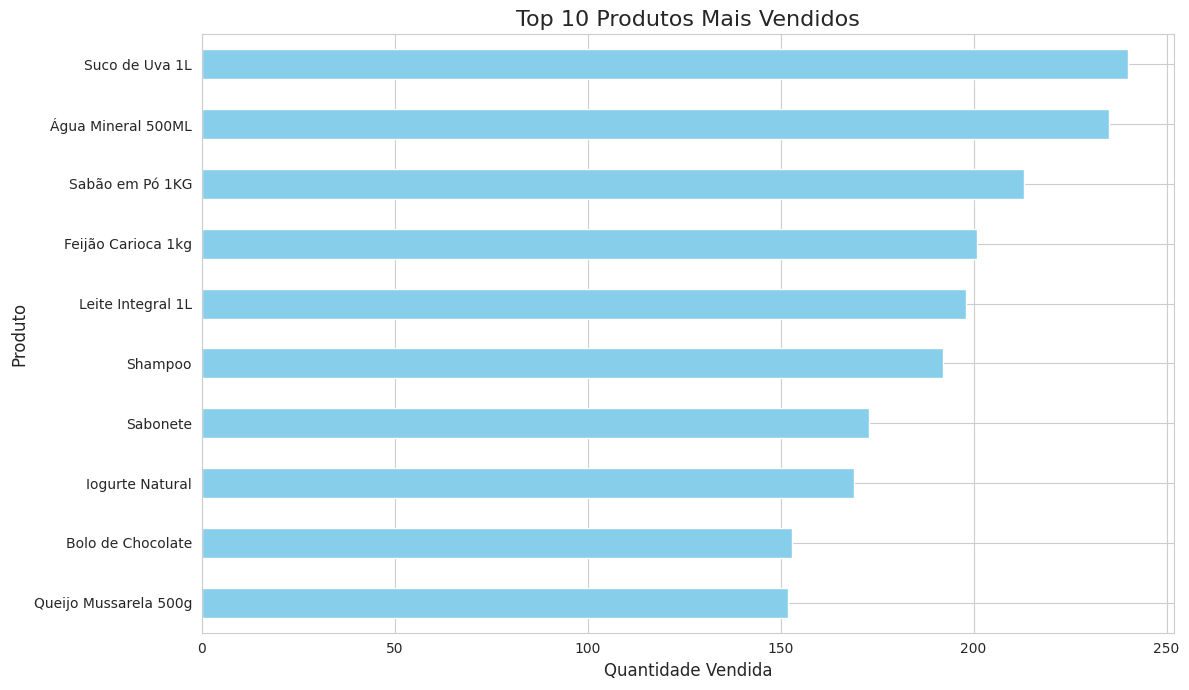

In [90]:
#Define um estilo para os gráficos
sns.set_style("whitegrid")
#Cria a figura e os eixos
plt.figure(figsize=(12,7))
#Cria o gráfico de barras horizontais
top10Vendidos.sort_values(ascending=True).plot(kind='barh', color = 'skyblue')
#Adiciona títulos e labels
plt.title('Top 10 Produtos Mais Vendidos', fontsize = 16)
plt.xlabel('Quantidade Vendida', fontsize = 12)
plt.ylabel('Produto', fontsize = 12)
#Exibe o gráfico
plt.tight_layout()
plt.show()


# **7 - Análise - Faturamento Por Mês**

In [91]:
df_vendas.head()

,ID_Pedido,Data_Pedido,Nome_Produto,Categoria,Preco_Unitario,Quantidade,ID_Cliente,Cidade,Estado,Faturamento,Status_Entrega
0,1000,2025-01-01 04:00:00,Queijo Mussarela 500g,Laticínios,18.00,5,126,Belo Horizonte,MG,90.00,Rápida
1,1001,2025-01-01 06:00:00,Macarrão Espaguete,Massas,4.20,8,113,Fortaleza,CE,33.60,Normal
2,1002,2025-01-01 20:00:00,Feijão Carioca 1kg,Alimentos Básicos,8.22,8,148,Rio de janeiro,RJ,65.76,Rápida
3,1003,2025-01-01 16:00:00,Pão de Forma,Padaria,11.45,2,130,Porto Alegre,RS,22.90,Normal
4,1004,2025-01-01 01:00:00,Refrigerante 2L,Bebidas,8.50,1,108,Porto Alegre,RS,8.50,Normal


In [92]:
#Cria uma coluna 'Mes' para facilitar o agrupamento mensal
df_vendas['Mes'] = df_vendas['Data_Pedido'].dt.to_period('M')

In [93]:
df_vendas.head()

,ID_Pedido,Data_Pedido,Nome_Produto,Categoria,Preco_Unitario,Quantidade,ID_Cliente,Cidade,Estado,Faturamento,Status_Entrega,Mes
0,1000,2025-01-01 04:00:00,Queijo Mussarela 500g,Laticínios,18.00,5,126,Belo Horizonte,MG,90.00,Rápida,2025-01
1,1001,2025-01-01 06:00:00,Macarrão Espaguete,Massas,4.20,8,113,Fortaleza,CE,33.60,Normal,2025-01
2,1002,2025-01-01 20:00:00,Feijão Carioca 1kg,Alimentos Básicos,8.22,8,148,Rio de janeiro,RJ,65.76,Rápida,2025-01
3,1003,2025-01-01 16:00:00,Pão de Forma,Padaria,11.45,2,130,Porto Alegre,RS,22.90,Normal,2025-01
4,1004,2025-01-01 01:00:00,Refrigerante 2L,Bebidas,8.50,1,108,Porto Alegre,RS,8.50,Normal,2025-01


In [94]:
#Agrupa por mês e soma o faturamento
faturamento_mensal = df_vendas.groupby('Mes')['Faturamento'].sum()

In [95]:
#Converte o índice para string para facilitar a plotagem no gráfico
faturamento_mensal.index = faturamento_mensal.index.strftime('%Y-%m')

In [96]:
#Formata para duas casas decimal
faturamento_mensal.map('R$ {:,.2f}'.format)

,Faturamento
Mes,
2025-01,"R$ 5,378.49"
2025-02,"R$ 5,887.76"
2025-03,"R$ 6,839.74"
2025-04,"R$ 5,547.58"
2025-05,"R$ 1,569.40"


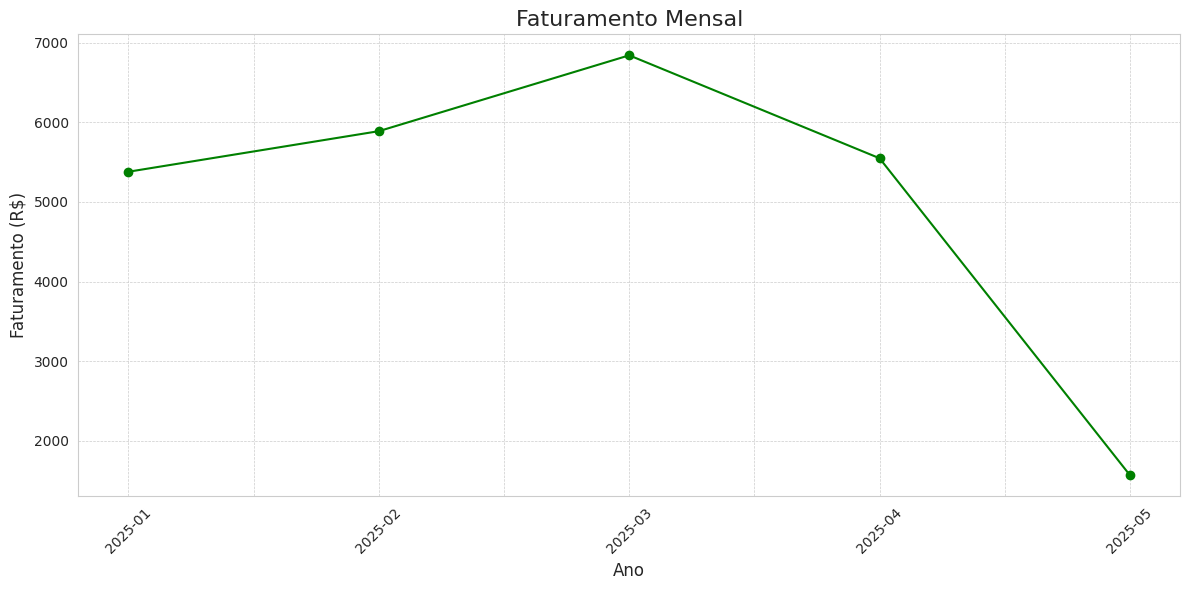

In [97]:
#Cria uma nova figura com tamanho de 12 por 6 polegadas
plt.figure(figsize = (12, 6))

#Plota os dados de faturamento mensal em formato de linha
faturamento_mensal.plot(kind = 'line', marker = 'o', linestyle = '-', color = 'green')

#Define o título do gráfico com fonte de tamanho 16
plt.title("Faturamento Mensal", fontsize = 16)

#Define o rótulo do eixo X
plt.xlabel("Ano", fontsize = 12)

#Define o rótulo do eixo Y
plt.ylabel("Faturamento (R$)", fontsize = 12)

#Rotaciona os valores do eixo X em 45 graus para melhor visualização
plt.xticks(rotation = 45)

#Adiciona uma grade com estilo tracejado e linhas finas
plt.grid(True, which = 'both', linestyle = '--', linewidth = 0.5)

#Ajusta automaticamente os elementos para evitar sobreposição
plt.tight_layout()

#Exibe o gráfico
plt.show()

# **8 - Análise - Vendas Por Estado**

In [98]:
#Agrupa por estado e soma o faturamento
vendas_estados = df_vendas.groupby('Estado')['Faturamento'].sum().sort_values(ascending=False)

In [99]:
#Formata para duas casas decimais
vendas_estados.map('R$ {:,.2f}'.format)

,Faturamento
Estado,
PR,"R$ 4,154.89"
RJ,"R$ 3,978.93"
RS,"R$ 3,967.14"
BA,"R$ 3,500.57"
SP,"R$ 3,253.19"
MG,"R$ 3,251.05"
CE,"R$ 3,117.20"


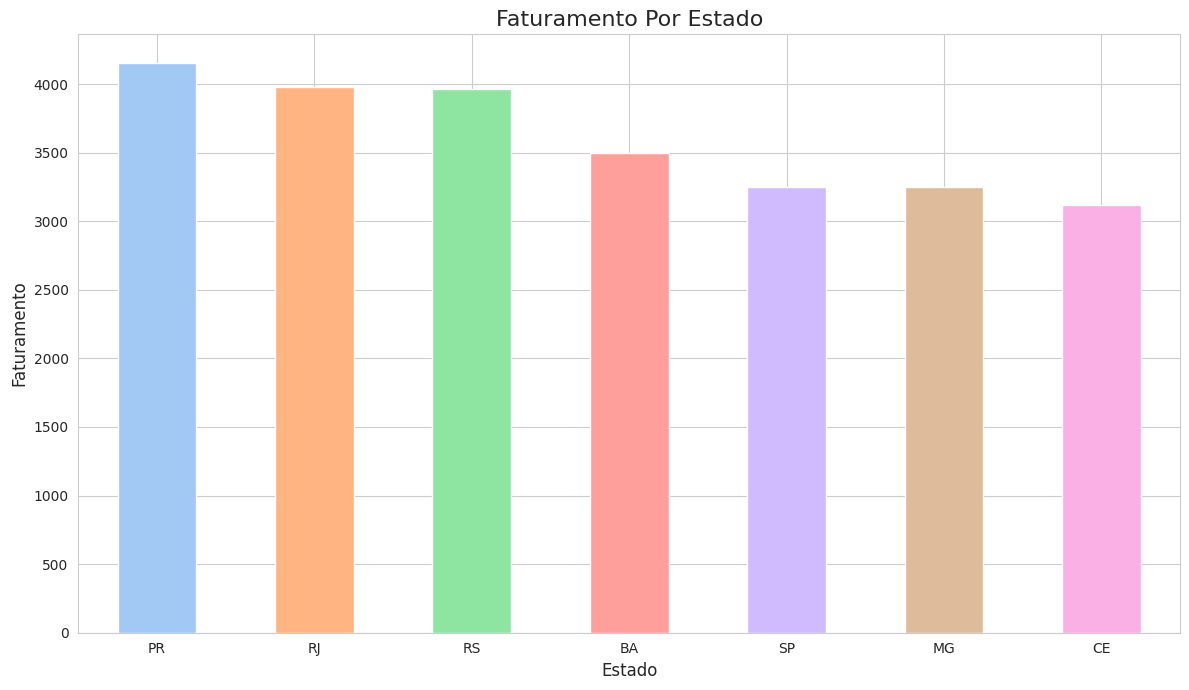

In [100]:
#Cria uma nova figura com tamanho de 12 por 7 polegadas
plt.figure(figsize = (12,7))

#Plota os dados de faturamento por estado em formato de gráfico de barras
#Usando a paleta de cores "rocket" do Seaborn
vendas_estados.plot(kind = 'bar', color = sns.color_palette("pastel"))

#Define o título do gráfico com fonte de tamanho 16
plt.title("Faturamento Por Estado", fontsize = 16)

#Define o rótulo do eixo X
plt.xlabel("Estado", fontsize = 12)

#Define o rótulo do eixo Y
plt.ylabel("Faturamento", fontsize = 12)

#Mantém os rótulos do eixo X na horizontal (sem rotação)
plt.xticks(rotation = 0)

#Ajusta automaticamente os elementos do gráfico para evitar sobreposição
plt.tight_layout()

#Exibe o gráfico
plt.show()

# **9 - Análise - Faturamento Por Categoria**

In [101]:
#Agrupa por categoria, soma o faturamento e formata como moeda para melhor leitura
categoria_faturamento = df_vendas.groupby('Categoria')['Faturamento'].sum().sort_values(ascending = False)

In [102]:
#O .map('{:,.2f}'.format) é opcional, mas deixa a visualização do número mais clara
categoria_faturamento.map('R$ {:,.2f}'.format)

,Faturamento
Categoria,
Alimentos Básicos,"R$ 5,491.52"
Higiene Pessoal,"R$ 4,715.00"
Laticínios,"R$ 4,307.60"
Padaria,"R$ 4,035.40"
Bebidas,"R$ 3,044.50"
Limpeza,"R$ 2,754.40"
Massas,R$ 625.80
Molhos,R$ 248.75


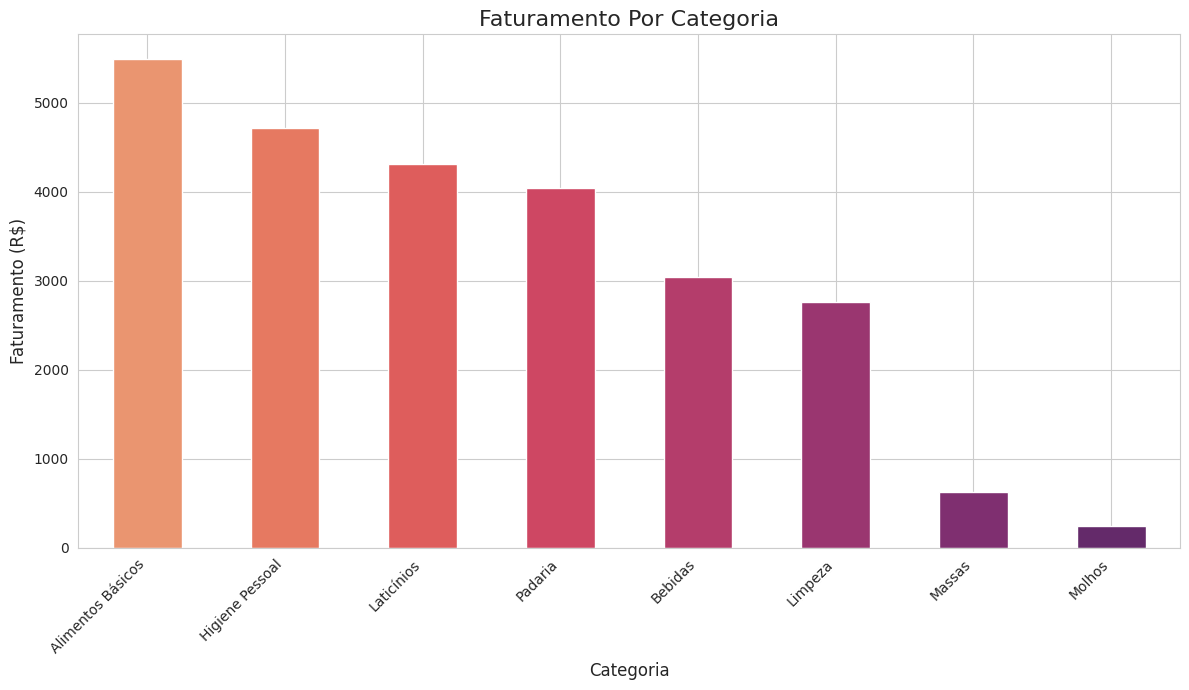

In [103]:
#Ordena os dados para o gráfico ficar mais fácil de ler
categoria_faturamento = categoria_faturamento.sort_values(ascending = False)

#Cria a Figura e os Eixos (ax) com plt.subplots()
#Isso nos dá mais controle sobre os elementos do gráfico.
plt.figure(figsize = (12,7))

#Plota os dados usando o objeto 'ax'
categoria_faturamento.plot(kind = 'bar', color = sns.color_palette("flare", len(categoria_faturamento)))

#Adiciona títulos e labels usando 'ax.set_...'
plt.title("Faturamento Por Categoria", fontsize = 16)
plt.xlabel("Categoria", fontsize = 12)
plt.ylabel("Faturamento (R$)", fontsize = 12)

#Ajusta a rotação dos rótulos do eixo X
plt.xticks(rotation = 45, ha = "right")

#Garante que tudo fique bem ajustado na imagem final
plt.tight_layout()

# Exibe o gráfico
plt.show()